In [2]:
import pandas as pd
import pypsa
import matplotlib.pyplot as plt
import numpy as np

In [14]:
# --- DATA PREPROCESSING ---
file_path = 'time_series_60min_singleindex.csv'

countries = ["CZ", "DE", "AT", "PL"]

target_columns = ["utc_timestamp"]
for c in countries:
    target_columns += [
        f"{c}_load_actual_entsoe_transparency",
        f"{c}_solar_generation_actual",
        f"{c}_wind_onshore_generation_actual"
    ]

df = pd.read_csv(file_path, usecols=target_columns, index_col=0, parse_dates=True)
df.index = df.index.tz_localize(None)

df_2019 = df.loc['2019-01-01':'2019-12-31'].copy().ffill().bfill().fillna(0)

# --- TECH DATA ---
def annuity(n, r):
    if r > 0:        
        return r / (1 - 1/(1+r)**n)
    else:
        return 1 / n

discount_rate = 0.07

# Gas marginal cost calculation
# Source: #https://www.sciencedirect.com/science/article/abs/pii/S036054421831288X?fr=RR-2&ref=pdf_download&rr=9ea337d92f634f62
fuel_cost_gas = 21.6 
vom_gas = 3.0        
gas_marginal = (fuel_cost_gas / 0.39) + vom_gas # 0.39 from gas efficiency

# Costs and parameters for each technology
# Source: #https://www.diw.de/documents/publikationen/73/diw_01.c.424566.de/diw_datadoc_2013-068.pdf
# Source: https://www.woodwayenergy.com/natural-gas-efficiency-in-power-generation/
tech_data = {
    'solar':       {'inv': 750000,  'fom': 0.03, 'life': 25, 'marg': 0.01,          'eff': 1.00,                            'color': "#f1c40f"},
    'wind':        {'inv': 1240000, 'fom': 0.03, 'life': 25, 'marg': 0.01,          'eff': 1.00,                            'color': "#3498db"},
    'nuclear':     {'inv': 6000000, 'fom': 0.025,'life': 40, 'marg': 11.5,          'eff': 1.00, 'avail': 0.9,              'color': "#e74c3c"},
    'coal':        {'inv': 1300000, 'fom': 0.02, 'life': 40, 'marg': 51.0,          'eff': 0.33, 'avail': 1.0, 'co2': 0.34, 'color': "#7f8c8d"},
    'gas':         {'inv': 400000,  'fom': 0.04, 'life': 30, 'marg': gas_marginal,  'eff': 0.39, 'avail': 1.0, 'co2': 0.19, 'color': "#e67e22"}
} # should we change eff?

# Installed capacities of solar and wind of each country for CF scaling
# Source: #https://transparency.entsoe.eu/generation/installed/perType?appState=%7B%22sa%22%3A%5B%22BZN%7C10YCZ-CEPS-----N%22%5D%2C%22st%22%3A%22BZN%22%2C%22mm%22%3Atrue%2C%22ma%22%3Afalse%2C%22sp%22%3A%22HALF%22%2C%22dt%22%3A%22CHART%22%2C%22df%22%3A%5B%222019%22%2C%222019%22%5D%2C%22tz%22%3A%22CET%22%7D
installed = {
    "CZ": {"solar": 2049,   "wind": 316},
    "DE": {"solar": 45435,  "wind": 52946},
    "PL": {"solar": 430,    "wind": 5808},
    "AT": {"solar": 1193,   "wind": 3035},
} 

# Capacity factors of solar and wind of each country
for c in countries:
    df_2019[f"{c}_solar_cf"] = (
        df_2019[f"{c}_solar_generation_actual"] / installed[c]["solar"]
    ).clip(0, 1)

    df_2019[f"{c}_wind_cf"] = (
        df_2019[f"{c}_wind_onshore_generation_actual"] / installed[c]["wind"]
    ).clip(0, 1)

# --- NETWORK ---
n = pypsa.Network()
n.set_snapshots(df_2019.index)

# Buses
n.add("Bus", countries)

# Carriers
for tech, d in tech_data.items():
    n.add("Carrier", tech, co2_emissions=d.get("co2", 0), color=d["color"])

# --- LOADS ---
for c in countries:
    n.add("Load", f"{c}_load",
          bus=c,
          p_set=df_2019[f"{c}_load_actual_entsoe_transparency"])

# --- GENERATORS ---
for c in countries:
    for tech, d in tech_data.items():

        name = f"{c}_{tech}"

        # Costs
        capital_cost = d['inv'] * (annuity(d['life'], discount_rate) + d['fom'])

        # Marginal cost + CF
        if  tech == "wind":
            marginal_cost = d["marg"]
            p_max_pu = df_2019[f"{c}_wind_cf"]
            efficiency = d["eff"]

        elif tech == "solar":
            marginal_cost = d["marg"]
            p_max_pu = df_2019[f"{c}_solar_cf"]
            efficiency = d["eff"]

        else:
            marginal_cost = d["marg"]
            p_max_pu = d["avail"]
            efficiency = d["eff"]

        n.add("Generator",
              name,
              bus = c,
              carrier = tech,
              p_nom_extendable = True,
              capital_cost = capital_cost,
              marginal_cost = marginal_cost,
              efficiency = efficiency,
              p_max_pu = p_max_pu)

# --- TRANSMISSION ---
# Capacities based on 2026 max physical flows between the countries
# Source: #https://transparency.entsoe.eu/transmission/physicalFlows?appState=%7B%22sa%22%3A%5B%22CTY%7C10YCZ-CEPS-----N%22%5D%2C%22st%22%3A%22CTY%22%2C%22mm%22%3Atrue%2C%22ma%22%3Afalse%2C%22sp%22%3A%22HALF%22%2C%22dt%22%3A%22TABLE%22%2C%22df%22%3A%222026-04-01%22%2C%22tz%22%3A%22CET%22%7D
lines = [
    ("CZ", "DE", 3500), # max: 3449
    ("CZ", "AT", 2500), # max: 2390
    ("CZ", "PL", 2500), # max: 2487
    ("DE", "PL", 3000), # max: 2820
]

for b0, b1, cap in lines:
    n.add("Line", f"{b0}-{b1}", 
          bus0=b0, 
          bus1=b1, 
          x=1, 
          s_nom=cap)

# --- OPTIMIZATION ---
n.optimize(solver_name="gurobi")

C:\Users\Bagus\AppData\Local\Temp\ipykernel_19684\143764211.py:134: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['CZ', 'DE', 'AT', 'PL'], dtype='str', name='name')
Index(['CZ-DE', 'CZ-AT', 'CZ-PL', 'DE-PL'], dtype='str', name='name')
Index(['CZ-DE', 'CZ-AT', 'CZ-PL', 'DE-PL'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 3/3 [00:00<00:00, 57.37it/s]
INFO:linopy.io: Writing time: 1.24s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2794134


INFO:gurobipy:Set parameter LicenseID to value 2794134


...

Solved in 128426 iterations and 7.26 seconds (3.67 work units)


INFO:gurobipy:Solved in 128426 iterations and 7.26 seconds (3.67 work units)


Optimal objective  5.167906240e+10


INFO:gurobipy:Optimal objective  5.167906240e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 210260 primals, 464300 duals
Objective: 5.17e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, Kirchhoff-Voltage-Law were not assigned to the network.


('ok', 'optimal')

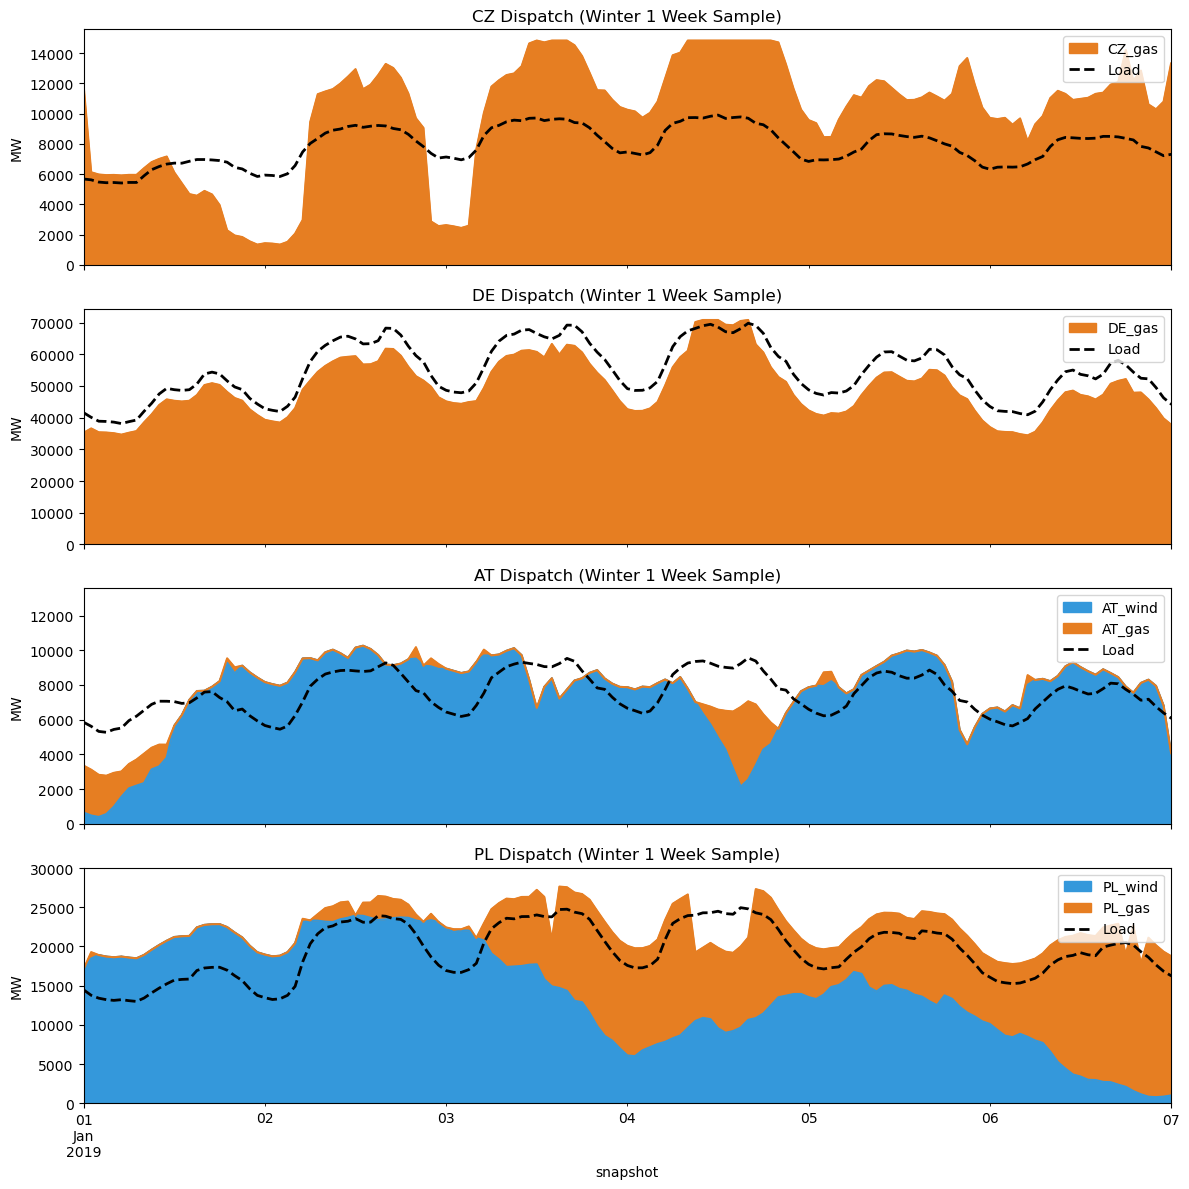

In [15]:
SIGNIFICANCE_THRESHOLD = 0.01  # drop generators contributing < 1% of total generation

# --- DISPATCH PLOT (WINTER) ---
fig, axes = plt.subplots(len(countries), 1, figsize=(12, 3*len(countries)), sharex=True)

for i, c in enumerate(countries):
    ax = axes[i] if len(countries) > 1 else axes

    gens = [g for g in n.generators.index if g.startswith(c)]
    gen_dispatch = n.generators_t.p[gens]
    total = gen_dispatch.sum().sum()
    significant_gens = [g for g in gens if gen_dispatch[g].sum() / total > SIGNIFICANCE_THRESHOLD]

    # Generation stack
    gen_dispatch[significant_gens].plot.area(
        ax=ax,
        color=[n.carriers.at[n.generators.at[g, "carrier"], "color"] for g in significant_gens]
    )

    # Load
    n.loads_t.p_set[f"{c}_load"].plot(
        ax=ax,
        color='black',
        linestyle='--',
        linewidth=2,
        label='Load'
    )

    ax.set_title(f"{c} Dispatch (Winter 1 Week Sample)")
    ax.set_ylabel("MW")
    ax.legend(loc='upper right')

plt.xlim("2019-01-01", "2019-01-07")
plt.tight_layout()
plt.show()

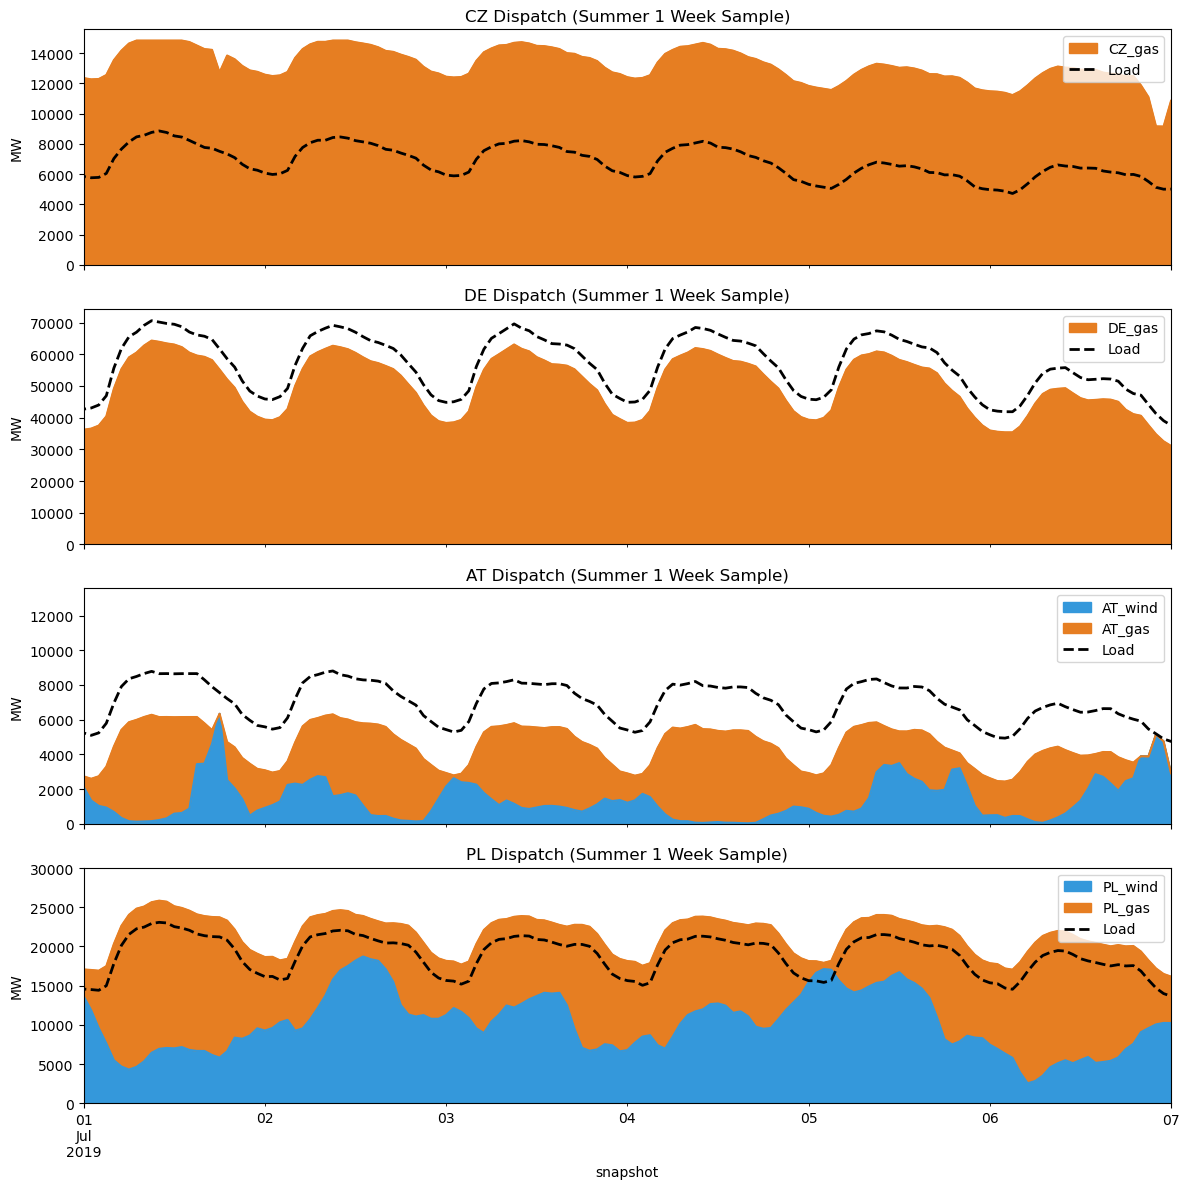

In [10]:
SIGNIFICANCE_THRESHOLD = 0.01  # drop generators contributing < 1% of total generation

# --- DISPATCH PLOT (SUMMER) ---
fig, axes = plt.subplots(len(countries), 1, figsize=(12, 3*len(countries)), sharex=True)

for i, c in enumerate(countries):
    ax = axes[i] if len(countries) > 1 else axes

    gens = [g for g in n.generators.index if g.startswith(c)]
    gen_dispatch = n.generators_t.p[gens]
    total = gen_dispatch.sum().sum()
    significant_gens = [g for g in gens if gen_dispatch[g].sum() / total > SIGNIFICANCE_THRESHOLD]

    # Generation stack
    gen_dispatch[significant_gens].plot.area(
        ax=ax,
        color=[n.carriers.at[n.generators.at[g, "carrier"], "color"] for g in significant_gens]
    )

    # Load
    n.loads_t.p_set[f"{c}_load"].plot(
        ax=ax,
        color='black',
        linestyle='--',
        linewidth=2,
        label='Load'
    )

    ax.set_title(f"{c} Dispatch (Summer 1 Week Sample)")
    ax.set_ylabel("MW")
    ax.legend(loc='upper right')

plt.xlim("2019-07-01", "2019-07-07")
plt.tight_layout()
plt.show()

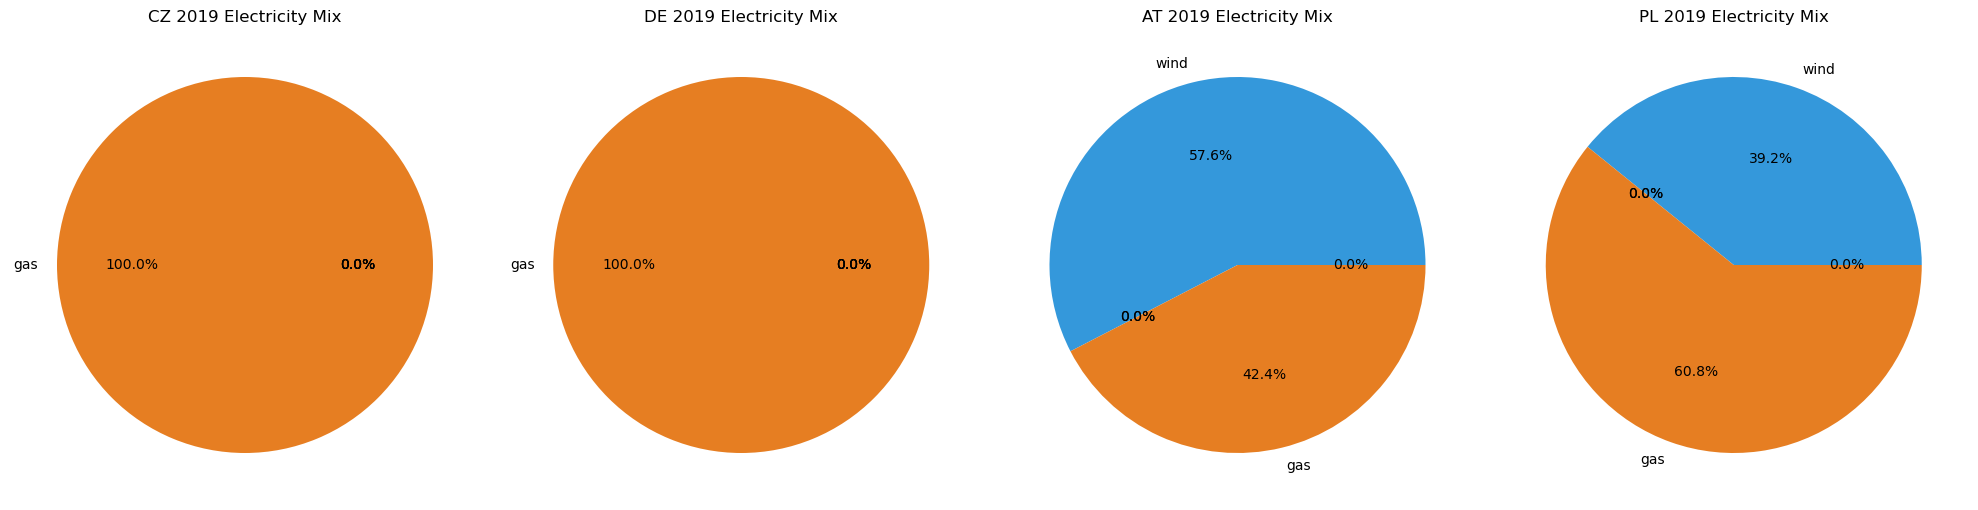

In [81]:
# --- ELECTRICITY MIX BY COUNTRY ---

fig, axes = plt.subplots(1, len(countries), figsize=(5*len(countries), 5))

for i, c in enumerate(countries):
    ax = axes[i] if len(countries) > 1 else axes

    gens = [g for g in n.generators.index if g.startswith(c)]

    gen_by_carrier = {}

    for g in gens:
        carrier = n.generators.at[g, "carrier"]
        energy = n.generators_t.p[g].sum()

        if carrier not in gen_by_carrier:
            gen_by_carrier[carrier] = 0

        gen_by_carrier[carrier] += energy

    # Convert to Series
    gen_by_carrier = pd.Series(gen_by_carrier)

    # Plot
    gen_by_carrier.plot(
        kind="pie",
        ax=ax,
        autopct="%1.1f%%",
        colors=[n.carriers.at[carr, "color"] for carr in gen_by_carrier.index]
    )

    ax.set_title(f"{c} 2019 Electricity Mix")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

In [71]:
gen_by_carrier

solar      0.000000e+00
wind       7.175964e+07
nuclear    0.000000e+00
coal       0.000000e+00
gas        9.543758e+07
dtype: float64

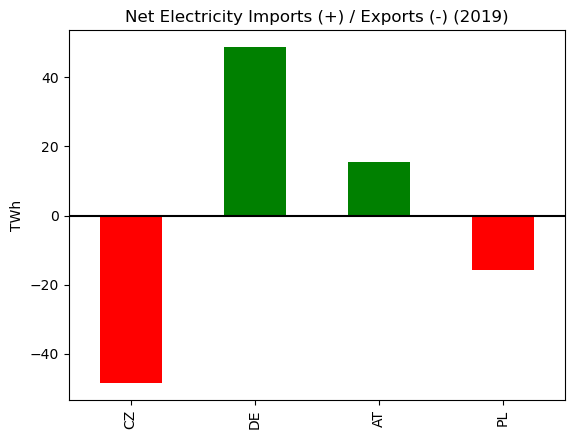


Net Imports (+) / Exports (-) [TWh]:
CZ   -48.450156
DE    48.760186
AT    15.473642
PL   -15.783673
dtype: float64


In [82]:
net_imports = {c: 0 for c in countries}

for line in n.lines.index:
    bus0 = n.lines.at[line, "bus0"]
    bus1 = n.lines.at[line, "bus1"]
    flow = n.lines_t.p0[line]

    net_imports[bus0] -= flow.sum()
    net_imports[bus1] += flow.sum()

net_imports = pd.Series(net_imports) / 1e6  # TWh

net_imports.plot(
    kind="bar",
    color=["green" if v > 0 else "red" for v in net_imports]
)

plt.axhline(0, color='black')
plt.ylabel("TWh")
plt.title("Net Electricity Imports (+) / Exports (-) (2019)")
plt.show()

print("\nNet Imports (+) / Exports (-) [TWh]:")
print(net_imports)

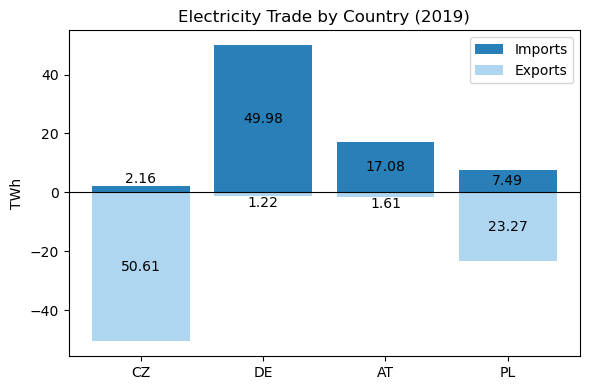

In [23]:
imports = {c: 0 for c in countries}
exports = {c: 0 for c in countries}

for line in n.lines.index:
    b0 = n.lines.at[line, "bus0"]
    b1 = n.lines.at[line, "bus1"]
    flow = n.lines_t.p0[line]

    exports[b0] += flow.clip(lower=0).sum()
    imports[b1] += flow.clip(lower=0).sum()
    exports[b1] += (-flow.clip(upper=0)).sum()
    imports[b0] += (-flow.clip(upper=0)).sum()

imports =  pd.Series(imports) / 1e6
exports = -pd.Series(exports) / 1e6  # negative

fig, ax = plt.subplots(figsize=(6, 4))

bars_i = ax.bar(countries, imports, color="#2980b9", label="Imports")
bars_e = ax.bar(countries, exports, color="#aed6f1", label="Exports")

MIN_LABEL = 7

for container in [bars_i, bars_e]:
    for bar in container:
        height = bar.get_height()
        if abs(height) > 0.05:
            if abs(height) < MIN_LABEL:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + height + (0.05 if height > 0 else -0.05),
                    f"{abs(height):.2f}",
                    ha="center", va="bottom" if height > 0 else "top",
                )
            else:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + height / 2,
                    f"{abs(height):.2f}",
                    ha="center", va="center",
                )

ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel("TWh")
ax.set_title("Electricity Trade by Country (2019)")
ax.legend()
plt.tight_layout()
plt.show()

In [92]:
flow_df = pd.DataFrame(0.0, index=countries, columns=countries)

for line in n.lines.index:
    b0 = n.lines.at[line, "bus0"]
    b1 = n.lines.at[line, "bus1"]
    
    flow = n.lines_t.p0[line]

    # energy in TWh
    b0_to_b1 = flow.clip(lower=0).sum() / 1e6
    b1_to_b0 = (-flow).clip(lower=0).sum() / 1e6

    flow_df.loc[b0, b1] += b0_to_b1
    flow_df.loc[b1, b0] += b1_to_b0

flow_df = flow_df.round(2)
flow_df["Total Export"] = flow_df.sum(axis=1)
flow_df.loc["Total Import"] = flow_df.sum(axis=0)

flow_df

,CZ,DE,AT,PL,Total Export
CZ,0.00,27.25,17.08,6.27,50.60
DE,0.01,0.00,0.00,1.21,1.22
AT,1.61,0.00,0.00,0.00,1.61
PL,0.54,22.73,0.00,0.00,23.27
Total Import,2.16,49.98,17.08,7.48,76.70


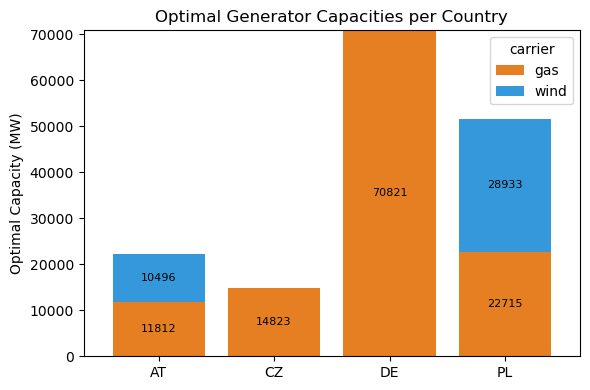

In [22]:
gen_caps = n.generators[["bus", "carrier", "p_nom_opt"]].copy()
gen_caps = gen_caps[gen_caps["p_nom_opt"] > 1]

pivot = gen_caps.pivot_table(index="bus", columns="carrier", values="p_nom_opt", aggfunc="sum")

fig, ax = plt.subplots(figsize=(6, 4))
pivot.plot.bar(ax=ax, stacked=True,
               color=[n.carriers.at[c, "color"] for c in pivot.columns],
               width=0.8)

for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 1:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + height / 2,
                f"{height:.0f}",
                ha="center", va="center",
                fontsize=8
            )

ax.set_ylabel("Optimal Capacity (MW)")
ax.set_title("Optimal Generator Capacities per Country")
ax.set_xlabel("")
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

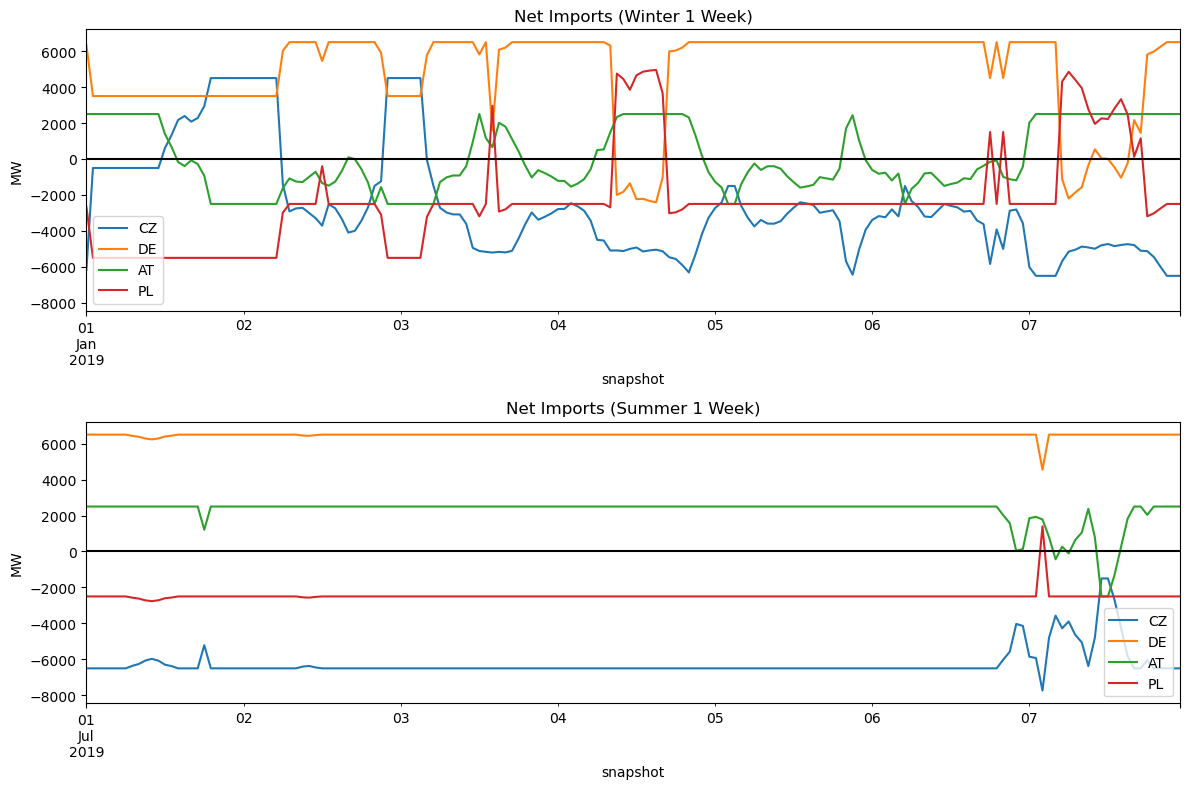

In [84]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharey=True)

weeks = {
    "Winter 1 Week": ("2019-01-01", "2019-01-07"),
    "Summer 1 Week": ("2019-07-01", "2019-07-07"),
}

for ax, (title, (start, end)) in zip(axes, weeks.items()):
    
    for c in countries:
        net = 0
        for line in n.lines.index:
            b0 = n.lines.at[line, "bus0"]
            b1 = n.lines.at[line, "bus1"]
            flow = n.lines_t.p0[line]

            if c == b0:
                net -= flow
            elif c == b1:
                net += flow

        # net = net.resample("6h").mean()
        net.loc[start:end].plot(ax=ax, label=c)

    ax.axhline(0, color='black')
    ax.set_title(f"Net Imports ({title})")
    ax.set_ylabel("MW")
    ax.legend()

plt.tight_layout()
plt.show()